# Host Classification
- Class-Conditional Validity Envelopes - Rather than constructing a single 35-dimensional envelope  
- No Imputation
- No Empty Sets

In [1]:
import os
import pickle
import time
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

### Loading the Data

In [2]:
DATA_DIR = "../Data"
SCORES_PATH = f"{DATA_DIR}/phage_host_scores.parquet"
METADATA_PATH = f"{DATA_DIR}/metadata.csv"
alpha = 0.1

print("Loading phage-level host scores...")
t0 = time.time()
phage_scores = pd.read_parquet(SCORES_PATH)
print(f"  shape : {phage_scores.shape}  ({time.time()-t0:.1f}s)")

print("Loading metadata...")
meta_df = pd.read_csv(METADATA_PATH, index_col="proteinID")
# One row per phage: take first protein's metadata per accession
phage_meta = (meta_df.reset_index().groupby("accession")[["host", "host_type", "split"]].first())
print(f"  phage_meta shape : {phage_meta.shape}")

Loading phage-level host scores...
  shape : (18443, 2036)  (0.9s)
Loading metadata...
  phage_meta shape : (18474, 3)


#### Joining scores with labels

In [3]:
phage_df = phage_scores.join(phage_meta, how="inner")
phage_df["split"] = phage_df["split"].astype(int)

print(f"\nPhage-level shape after join: {phage_df.shape}")
print("\nSplit distribution:")
print(phage_df["split"].value_counts().sort_index())
print("\nHost distribution (top 15):")
print(phage_df["host"].value_counts().head(15))


Phage-level shape after join: (18443, 2039)

Split distribution:
split
0    4422
1    3169
2    3638
3    3584
4    3630
Name: count, dtype: int64

Host distribution (top 15):
host
Mycobacterium     2352
Escherichia       2254
Pseudomonas       1023
Klebsiella         966
Salmonella         958
Vibrio             917
Streptococcus      740
Gordonia           657
Staphylococcus     652
Microbacterium     545
Bacillus           440
Ralstonia          412
Arthrobacter       397
Synechococcus      392
Lactococcus        388
Name: count, dtype: int64


#### Identifying the score columns and host 

In [4]:
score_cols = [c for c in phage_scores.columns]

# Host genus = prefix before first underscore
all_hosts = sorted(set(c.split("_")[0] for c in score_cols))
print(f"Host: {len(all_hosts)}")
print(all_hosts)

# Map each host to its column indices
host_col_map = {h: [i for i, c in enumerate(score_cols) if c.split("_")[0] == h] for h in all_hosts}
print("\nColumns per host (sample):")
for h in all_hosts:
    print(f"  {h}: {len(host_col_map[h])} columns")

Host: 54
['Campylobacter', 'Caulobacter', 'Cellulophaga', 'Citrobacter', 'Clostridioides', 'Clostridium', 'Corynebacterium', 'Cronobacter', 'Dickeya', 'Edwardsiella', 'Enterobacter', 'Enterococcus', 'Erwinia', 'Escherichia', 'Flavobacterium', 'Gordonia', 'Haloarcula', 'Halorubrum', 'Klebsiella', 'Lacticaseibacillus', 'Lactobacillus', 'Lactococcus', 'Listeria', 'Microbacterium', 'Microcystis', 'Mycobacterium', 'Paenibacillus', 'Pantoea', 'Pectobacterium', 'Pelagibacter', 'Prochlorococcus', 'Propionibacterium', 'Proteus', 'Providencia', 'Pseudoalteromonas', 'Pseudomonas', 'Ralstonia', 'Rhizobium', 'Rhodobacter', 'Roseobacter', 'Salmonella', 'Serratia', 'Shewanella', 'Shigella', 'Sinorhizobium', 'Staphylococcus', 'Stenotrophomonas', 'Streptococcus', 'Streptomyces', 'Sulfolobus', 'Synechococcus', 'Vibrio', 'Xanthomonas', 'Yersinia']

Columns per host (sample):
  Campylobacter: 40 columns
  Caulobacter: 40 columns
  Cellulophaga: 36 columns
  Citrobacter: 40 columns
  Clostridioides: 36 col

### Train Test Split

In [5]:
phage_df = phage_df[phage_df["host"].isin(all_hosts)].copy()

train_df = phage_df[phage_df["split"] != 0].copy()
test_df = phage_df[phage_df["split"] == 0].copy()

print(f"Training phages (folds 1-4) : {len(train_df)}")
print(f"Test phages     (fold 0)    : {len(test_df)}")
print(f"\nTest host distribution:")
print(test_df["host"].value_counts())

Training phages (folds 1-4) : 11694
Test phages     (fold 0)    : 3944

Test host distribution:
host
Escherichia           856
Mycobacterium         497
Vibrio                279
Staphylococcus        235
Pseudomonas           196
Ralstonia             183
Salmonella            182
Klebsiella            168
Synechococcus         168
Streptococcus         160
Microbacterium        123
Propionibacterium     106
Gordonia               81
Enterococcus           72
Sulfolobus             55
Lactococcus            51
Shigella               46
Erwinia                38
Pelagibacter           31
Clostridium            29
Halorubrum             28
Flavobacterium         28
Yersinia               27
Streptomyces           22
Lactobacillus          21
Caulobacter            20
Rhizobium              19
Listeria               17
Cronobacter            16
Roseobacter            15
Enterobacter           15
Serratia               15
Pseudoalteromonas      14
Haloarcula             13
Corynebacterium

### Score characteristics
 -  For each host, the columns specific to that host should have higher mean scores for phages that actually infect that host.

In [6]:
print("Mean score at true-host columns vs all columns (training set):")
sample_hosts = all_hosts[:5]
for h in sample_hosts:
    h_idx = host_col_map[h]
    mask_h = train_df["host"] == h
    if mask_h.sum() == 0:
        continue
    true_host_mean = np.nanmean(train_df.loc[mask_h, score_cols].values[:, h_idx])
    all_mean = np.nanmean(train_df.loc[mask_h, score_cols].values)
    print(f"  {h}: true-host cols mean={true_host_mean:.3f}, "
          f"all cols mean={all_mean:.3f}, n={mask_h.sum()}")

Mean score at true-host columns vs all columns (training set):
  Campylobacter: true-host cols mean=0.207, all cols mean=0.052, n=96
  Caulobacter: true-host cols mean=0.271, all cols mean=0.058, n=31
  Cellulophaga: true-host cols mean=0.262, all cols mean=0.051, n=45
  Citrobacter: true-host cols mean=0.072, all cols mean=0.053, n=39
  Clostridioides: true-host cols mean=0.368, all cols mean=0.091, n=17


### Score Transformation
 -  For host classification: NC = 1 - raw_score
 - High raw score = strong infection evidence = low nonconformity

In [7]:
def raw_to_nc(raw_array):
    return np.where(np.isnan(raw_array), np.nan, 1.0 - raw_array)

train_raw = train_df[score_cols].values   # (n_train, K)
test_raw = test_df[score_cols].values    # (n_test,  K)
train_labels = train_df["host"].to_numpy(dtype=str)
test_labels = test_df["host"].to_numpy(dtype=str)

train_nc = raw_to_nc(train_raw)
test_nc = raw_to_nc(test_raw)

print(f"Train NC shape: {train_nc.shape}")
print(f"Test NC shape : {test_nc.shape}")
print(f"NaN fraction in train NC: {np.isnan(train_nc).mean():.3f}")
print(f"NaN fraction in test NC : {np.isnan(test_nc).mean():.3f}")

Train NC shape: (11694, 2036)
Test NC shape : (3944, 2036)
NaN fraction in train NC: 0.623
NaN fraction in test NC : 0.631


### Functions

In [8]:
def quantile_for_class(tau_scores, labels, cls, alpha):
    vals = np.sort(tau_scores[labels == cls])
    n = len(vals)
    if n == 0:
        return 0.0
    idx = int(np.ceil((n + 1) * (1 - alpha))) - 1
    return vals[np.clip(idx, 0, n - 1)]


def compute_t_hat_multiclass(tau_scores, labels, classes, alpha):
    """t_hat = max over all classes of the per-class (1-alpha) quantile."""
    return max(quantile_for_class(tau_scores, labels, c, alpha) for c in classes)

### 1D Collapsed Envelope

In [9]:
def collapsed_build_envelope(S1, S2, labels_S2, classes, alpha):
    S1_1d = np.nanmean(S1, axis=1, keepdims=True)
    S2_1d = np.nanmean(S2, axis=1, keepdims=True)
    q_tilde = np.nanquantile(S1_1d, 1 - alpha)
    tau_scores = (S2_1d / (q_tilde + 1e-12)).ravel()
    t_hat = compute_t_hat_multiclass(tau_scores, labels_S2, classes, alpha)
    return {"q_tilde": q_tilde, "t_hat": t_hat, "method": "collapsed"}


def collapsed_tau(scores, envelope):
    scores_1d = np.nanmean(scores, axis=1)
    return scores_1d / (envelope["q_tilde"] * envelope["t_hat"] + 1e-12)


def collapsed_is_in_region(scores, envelope):
    return np.nanmean(scores, axis=1) <= envelope["q_tilde"] * envelope["t_hat"]

### Radial Envelope

In [10]:
def sample_positive_sphere(M, K):
    V = np.abs(np.random.randn(M, K))
    return V / (np.linalg.norm(V, axis=1, keepdims=True) + 1e-12)


def radial_build_envelope(S1, S2, labels_S2, classes, alpha, M=200, delta_deg=30):
    N1, K = S1.shape
    U = sample_positive_sphere(M, K)
    cos_thresh = np.cos(np.radians(delta_deg))

    mags = np.array([np.linalg.norm(S1[n, ~np.isnan(S1[n])]) for n in range(N1)])
    dirs = np.zeros((N1, K))
    for n in range(N1):
        valid = ~np.isnan(S1[n])
        if mags[n] > 1e-12:
            dirs[n, valid] = S1[n, valid] / mags[n]

    q_tilde = np.zeros(M)
    for m in range(M):
        cos_sims = dirs @ U[m]
        nearby = cos_sims >= cos_thresh
        src_mags = mags[nearby] if nearby.sum() > 5 else mags
        q_tilde[m] = np.quantile(src_mags, 1 - alpha)

    N2 = S2.shape[0]
    tau_scores = np.zeros(N2)
    boundary = U * q_tilde[:, None]
    for n in range(N2):
        valid = ~np.isnan(S2[n])
        if valid.sum() == 0:
            tau_scores[n] = 0.0
            continue
        ratios_m = (S2[n, valid][None, :] /
                    (boundary[:, valid] + 1e-12)).max(axis=1)
        tau_scores[n] = ratios_m.min()

    t_hat = compute_t_hat_multiclass(tau_scores, labels_S2, classes, alpha)
    return {"U": U, "q_tilde": q_tilde, "t_hat": t_hat, "method": "radial"}


def radial_tau(scores, envelope):
    U, q_tilde, t_hat = envelope["U"], envelope["q_tilde"], envelope["t_hat"]
    boundary = U * (q_tilde * t_hat)[:, None]
    N = scores.shape[0]
    tau = np.zeros(N)
    for n in range(N):
        valid = ~np.isnan(scores[n])
        if valid.sum() == 0:
            tau[n] = 0.0
            continue
        ratios_m = (scores[n, valid][None, :] / (boundary[:, valid] + 1e-12)).max(axis=1)
        tau[n] = ratios_m.min()
    return tau


def radial_is_in_region(scores, envelope):
    U, q_tilde, t_hat = envelope["U"], envelope["q_tilde"], envelope["t_hat"]
    boundary = U * (q_tilde * t_hat)[:, None]
    N = scores.shape[0]
    inside = np.zeros(N, dtype=bool)
    for n in range(N):
        valid = ~np.isnan(scores[n])
        if valid.sum() == 0:
            inside[n] = True
            continue
        inside[n] = np.any(np.all(scores[n, valid][None, :] <= boundary[:, valid], axis=1))
    return inside

### Strip Envelope

In [11]:
def strip_shape_discovery(S1, alpha, M):
    N1, K = S1.shape
    bin_edges = np.array([
        np.linspace(np.nanmin(S1[:, j]), np.nanmax(S1[:, j]), M + 1)
        for j in range(K)
    ])
    limits = np.zeros((K, K, M))
    marginal_quantiles = np.array([
        np.nanquantile(S1[:, i], 1 - alpha) for i in range(K)
    ])
    for j in range(K):
        for m in range(M):
            lo, hi = bin_edges[j, m], bin_edges[j, m + 1]
            in_strip = (~np.isnan(S1[:, j])) & (S1[:, j] >= lo) & (S1[:, j] < hi)
            for i in range(K):
                if i == j:
                    continue
                src_mask = in_strip & (~np.isnan(S1[:, i]))
                if src_mask.sum() >= 3:
                    limits[j, i, m] = np.quantile(S1[src_mask, i], 1 - alpha)
                else:
                    non_nan_i = S1[~np.isnan(S1[:, i]), i]
                    limits[j, i, m] = (
                        np.quantile(non_nan_i, 1 - alpha)
                        if len(non_nan_i) > 0 else marginal_quantiles[i]
                    )
    for j in range(K):
        for i in range(K):
            if i == j:
                continue
            for m in range(M - 2, -1, -1):
                limits[j, i, m] = max(limits[j, i, m], limits[j, i, m + 1])
    return bin_edges, limits, marginal_quantiles


def get_bin_indices(scores, bin_edges):
    K = scores.shape[1]
    M = bin_edges.shape[1] - 1
    return np.array([np.clip(np.where(np.isnan(scores[:, j]), 0, np.digitize(scores[:, j], bin_edges[j]) - 1), 0, M - 1) for j in range(K)]).T


def strip_tau_scores(S, bin_edges, limits, marginal_quantiles):
    """Vectorised version — avoids the inner (j, i) Python loop."""
    N, K = S.shape
    bin_idx = get_bin_indices(S, bin_edges)   # (N, K)

    # Advanced indexing with broadcasting directly constructs the (N, K, K) array
    j_idx = np.arange(K)[None, :, None]
    i_idx = np.arange(K)[None, None, :]
    m_idx = bin_idx[:, :, None]
    
    lims = limits[j_idx, i_idx, m_idx]   # (N, K, K)

    S_i = S[:, np.newaxis, :]        # (N, 1, K) — broadcast over j
    S_j = S[:, :, np.newaxis]        # (N, K, 1) — broadcast over i

    nan_i = np.isnan(S_i)  # (N, 1, K)
    nan_j = np.isnan(S_j)  # (N, K, 1)

    mq = marginal_quantiles[np.newaxis, np.newaxis, :]  # (1, 1, K)

    ratio = np.zeros((N, K, K))

    both_avail = (~nan_i) & (~nan_j)   # (N, K, K)
    miss_i = nan_i & (~nan_j)

    # Standard: s_i / lim
    ratio = np.where(both_avail, np.broadcast_to(S_i, (N, K, K)) / (lims + 1e-12), ratio)
    # Missing dim i: marginal / lim
    ratio = np.where(miss_i, np.broadcast_to(mq, (N, K, K)) / (lims + 1e-12), ratio)

    # Zero out diagonal (i == j)
    diag_mask = np.eye(K, dtype=bool)[np.newaxis, :, : ]
    ratio = np.where(diag_mask, 0.0, ratio)

    return ratio.max(axis=(1, 2))


def strip_build_envelope(S1, S2, labels_S2, classes, alpha, M=20):
    bin_edges, limits, marginal_quantiles = strip_shape_discovery(S1, alpha, M)
    tau_scores = strip_tau_scores(S2, bin_edges, limits, marginal_quantiles)
    t_hat = compute_t_hat_multiclass(tau_scores, labels_S2, classes, alpha)
    return {
        "bin_edges": bin_edges,
        "limits": limits,
        "marginal_quantiles": marginal_quantiles,
        "t_hat": t_hat,
        "method": "strip"
    }


def strip_tau(scores, envelope):
    raw = strip_tau_scores(scores, envelope["bin_edges"], envelope["limits"], envelope["marginal_quantiles"])
    return raw / (envelope["t_hat"] + 1e-12)


def strip_is_in_region(scores, envelope):
    tau = strip_tau_scores(scores, envelope["bin_edges"], envelope["limits"], envelope["marginal_quantiles"])
    return tau <= envelope["t_hat"]

In [12]:
def is_in_region(scores, envelope):
    if envelope["method"] == "radial":
        return radial_is_in_region(scores, envelope)
    elif envelope["method"] == "strip":
        return strip_is_in_region(scores, envelope)
    return collapsed_is_in_region(scores, envelope)


def compute_tau(scores, envelope):
    if envelope["method"] == "collapsed":
        return collapsed_tau(scores, envelope)
    elif envelope["method"] == "strip":
        return strip_tau(scores, envelope)
    return radial_tau(scores, envelope)

### Envelope construction
- Building an envelope per host. 
- For each host
    - Extract only the K_h columns specific to host h
    - Build a separate envelope calibrated on training phages with true host h
    - At test time, check each hypothesis h using its K_h-dim NC sub-vector

In [13]:
def build_per_host_envelopes(train_nc, train_labels, all_hosts, score_cols, host_col_map, alpha,
                              method="collapsed", seed=42):
    rng = np.random.default_rng(seed)
    envelopes = {}

    for h in all_hosts:
        h_idx = host_col_map[h]
        if len(h_idx) == 0:
            continue

        mask_h = train_labels == h
        n_h = mask_h.sum()
        if n_h < 6:
            # Too few training phages to split S1/S2 meaningfully
            print(f"  SKIP {h}: only {n_h} training phages")
            continue

        train_nc_h = train_nc[mask_h][:, h_idx]   # (n_h, K_h)

        # 50/50 shuffle split into S1 and S2
        idx = rng.permutation(n_h)
        half = n_h // 2
        S1 = train_nc_h[idx[:half]]
        S2 = train_nc_h[idx[half:]]
        labels_S2 = np.array([h] * len(S2))

        if method == "collapsed":
            env = collapsed_build_envelope(S1, S2, labels_S2, [h], alpha)
        elif method == "radial":
            env = radial_build_envelope(S1, S2, labels_S2, [h], alpha)
        else:
            env = strip_build_envelope(S1, S2, labels_S2, [h], alpha)

        envelopes[h] = {"envelope": env, "col_indices": h_idx}

    print(f"  Built {len(envelopes)} host envelopes")
    return envelopes

### Host prediction

In [14]:
def predict_host(test_raw, per_host_envelopes, all_hosts):
    """
    Vectorised: for each host h, check ALL test phages at once.
    Builds an (N, n_hosts) boolean matrix, then assembles prediction sets.
    """
    N = len(test_raw)
    active_hosts = [h for h in all_hosts if h in per_host_envelopes]
    n_h = len(active_hosts)

    # inside[i, j] = True if phage i is inside host j's envelope
    inside_matrix = np.zeros((N, n_h), dtype=bool)
    tau_matrix = np.zeros((N, n_h), dtype=float)

    for j, h in enumerate(active_hosts):
        h_idx = per_host_envelopes[h]["col_indices"]
        env_h = per_host_envelopes[h]["envelope"]

        # NC sub-vectors for ALL test phages at once — shape (N, K_h)
        raw_h = test_raw[:, h_idx]
        nc_h = np.where(np.isnan(raw_h), np.nan, 1.0 - raw_h)

        inside_matrix[:, j] = is_in_region(nc_h, env_h)
        tau_matrix[:, j] = compute_tau(nc_h, env_h)

    # Assemble results from the matrices
    results = []
    for i in range(N):
        pred_set = [active_hosts[j] for j in range(n_h) if inside_matrix[i, j]]
        forced = False
        if len(pred_set) == 0:
            forced = True
            best_j = int(np.argmin(tau_matrix[i]))
            pred_set = [active_hosts[best_j]]
        results.append({
            "prediction_set": pred_set,
            "forced":         forced,
            "tau_per_host":   {active_hosts[j]: tau_matrix[i, j]
                               for j in range(n_h)}
        })
    return results

#### Evaluation

In [15]:
def evaluate_multiclass(results, true_labels, all_hosts, alpha):
    n = len(results)
    set_sizes = [len(r["prediction_set"]) for r in results]
    covered = sum(
        true_labels[i] in r["prediction_set"] for i, r in enumerate(results)
    )
    forced = sum(r["forced"] for r in results)
    singletons = [(r, true_labels[i]) for i, r in enumerate(results) if len(r["prediction_set"]) == 1]

    correct_singletons = sum(r["prediction_set"][0] == lbl for r, lbl in singletons)

    per_host_coverage = {}
    for h in all_hosts:
        h_idx = [i for i, lbl in enumerate(true_labels) if lbl == h]
        if not h_idx:
            continue
        per_host_coverage[h] = sum(true_labels[i] in results[i]["prediction_set"] for i in h_idx) / len(h_idx)

    return {
        "coverage":           covered / n,
        "avg_set_size":       np.mean(set_sizes),
        "singleton_rate":     len(singletons) / n,
        "singleton_accuracy": (correct_singletons / len(singletons)
                               if singletons else None),
        "forced_rate":        forced / n,
        "set_sizes":          set_sizes,
        "per_host_coverage":  per_host_coverage,
        "min_host_coverage":  min(per_host_coverage.values())
                              if per_host_coverage else None,
    }

### Evaluating on split 0 phages

In [16]:
print("\n" + "="*60)
print(" BUILDING PER-HOST ENVELOPES & TESTING ON SPLIT 0 ")
print("="*60)

# Start with collapsed — fastest, verify correctness first
print("\nBuilding collapsed envelopes...")
t0 = time.time()
per_host_envs_c = build_per_host_envelopes(
    train_nc, train_labels, all_hosts,
    score_cols, host_col_map, alpha,
    method="collapsed", seed=42
)
print(f"  Done ({time.time()-t0:.1f}s)")

print("\nPredicting on split 0...")
t0 = time.time()
collapsed_results = predict_host(test_raw, per_host_envs_c, all_hosts)
print(f"  Done ({time.time()-t0:.1f}s)")

collapsed_metrics = evaluate_multiclass(
    collapsed_results, test_labels, all_hosts, alpha
)

print(f"\n--- COLLAPSED RESULTS ---")
print(f"  Coverage           : {collapsed_metrics['coverage']:.3f}  "
      f"(target >= {1-alpha:.2f})")
print(f"  Avg set size       : {collapsed_metrics['avg_set_size']:.2f}  "
      f"(out of {len(all_hosts)} hosts)")
print(f"  Singleton rate     : {collapsed_metrics['singleton_rate']:.3f}")
print(f"  Singleton accuracy : {collapsed_metrics['singleton_accuracy']}")
print(f"  Forced rate        : {collapsed_metrics['forced_rate']:.3f}")
print(f"  Min per-host cov.  : {collapsed_metrics['min_host_coverage']:.3f}")


 BUILDING PER-HOST ENVELOPES & TESTING ON SPLIT 0 

Building collapsed envelopes...
  Built 54 host envelopes
  Done (0.1s)

Predicting on split 0...
  Done (0.2s)

--- COLLAPSED RESULTS ---
  Coverage           : 0.928  (target >= 0.90)
  Avg set size       : 7.15  (out of 54 hosts)
  Singleton rate     : 0.171
  Singleton accuracy : 0.8696296296296296
  Forced rate        : 0.005
  Min per-host cov.  : 0.000


In [17]:
h = all_hosts[4]
print(f"Host: {h}")
print(f"Number of columns for {h}: {len(host_col_map[h])}")
print(f"Number of training phages for {h}: {(train_labels == h).sum()}")

Host: Clostridioides
Number of columns for Clostridioides: 36
Number of training phages for Clostridioides: 17


#### Evaluating using radial and strip methods

In [18]:
print("\nBuilding radial envelopes...")
t0 = time.time()
per_host_envs_r = build_per_host_envelopes(train_nc, train_labels, all_hosts, score_cols, host_col_map, alpha,
                                           method="radial", seed=42)
print(f"  Done ({time.time()-t0:.1f}s)")

radial_results = predict_host(test_raw, per_host_envs_r, all_hosts)
radial_metrics = evaluate_multiclass(radial_results, test_labels, all_hosts, alpha)


Building radial envelopes...
  Built 54 host envelopes
  Done (1.1s)


In [19]:
print("\nBuilding strip envelopes...")
t0 = time.time()
per_host_envs_s = build_per_host_envelopes(train_nc, train_labels, all_hosts, score_cols, host_col_map, alpha,
                                            method="strip", seed=42)
print(f"  Done ({time.time()-t0:.1f}s)")


Building strip envelopes...
  Built 54 host envelopes
  Done (106.3s)


In [20]:
strip_results = predict_host(test_raw, per_host_envs_s, all_hosts)
strip_metrics = evaluate_multiclass(strip_results, test_labels, all_hosts, alpha)

### Summary

In [21]:
methods_names = ["Radial", "Strip", "Collapsed 1D"]
all_metrics = [radial_metrics, strip_metrics, collapsed_metrics]

rows = []
for name, m in zip(methods_names, all_metrics):
    rows.append({
        "Method":           name,
        "Coverage":         f"{m['coverage']:.3f}",
        "Avg set size":     f"{m['avg_set_size']:.2f}",
        "Singleton rate":   f"{m['singleton_rate']:.3f}",
        "Singleton acc.":   f"{m['singleton_accuracy']:.3f}"
                            if m["singleton_accuracy"] else "N/A",
        "Forced rate":      f"{m['forced_rate']:.3f}",
        "Min host cov.":    f"{m['min_host_coverage']:.3f}"
                            if m["min_host_coverage"] else "N/A",
    })

print("=== DEFINITIVE HELD-OUT TEST RESULTS (FOLD 0) ===")
print(pd.DataFrame(rows).to_string(index=False))

=== DEFINITIVE HELD-OUT TEST RESULTS (FOLD 0) ===
      Method Coverage Avg set size Singleton rate Singleton acc. Forced rate Min host cov.
      Radial    0.933        43.03          0.000            N/A       0.000           N/A
       Strip    0.426        15.28          0.000            N/A       0.000           N/A
Collapsed 1D    0.928         7.15          0.171          0.870       0.005           N/A


### Plots

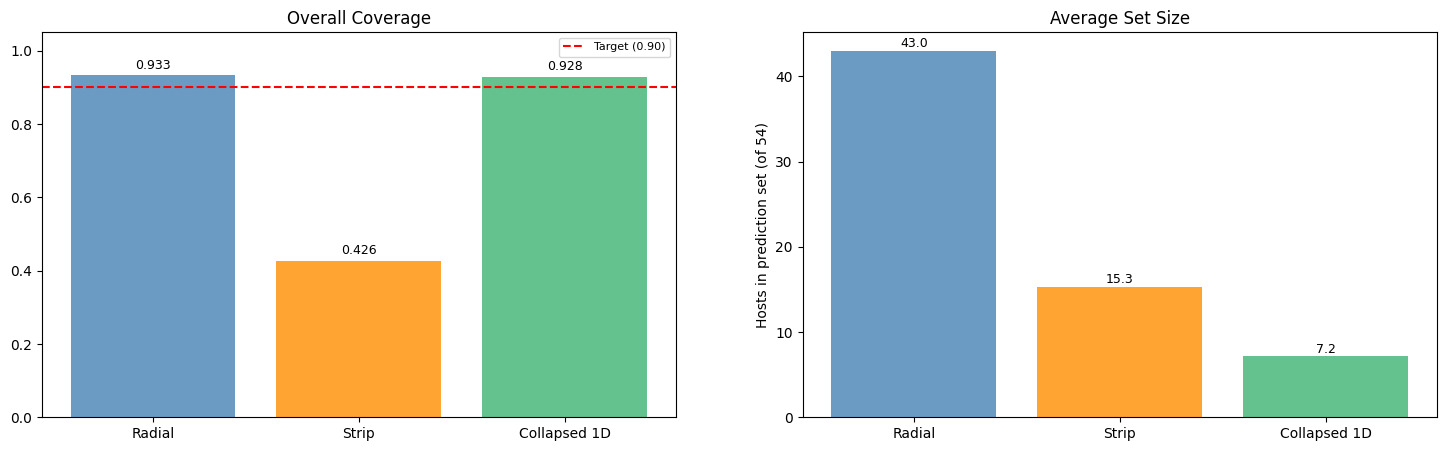

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
colors = ["steelblue", "darkorange", "mediumseagreen"]

# Overall coverage
ax = axes[0]
vals = [m["coverage"] for m in all_metrics]
bars = ax.bar(methods_names, vals, color=colors, alpha=0.8)
ax.axhline(1 - alpha, color="red", linestyle="--",
           label=f"Target ({1-alpha:.2f})")
ax.set_ylim(0, 1.05)
ax.set_title("Overall Coverage")
ax.legend(fontsize=8)
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
            f"{val:.3f}", ha="center", va="bottom", fontsize=9)

# Average set size
ax = axes[1]
vals = [m["avg_set_size"] for m in all_metrics]
bars = ax.bar(methods_names, vals, color=colors, alpha=0.8)
ax.set_title("Average Set Size")
ax.set_ylabel(f"Hosts in prediction set (of {len(all_hosts)})")
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.1,
            f"{val:.1f}", ha="center", va="bottom", fontsize=9)

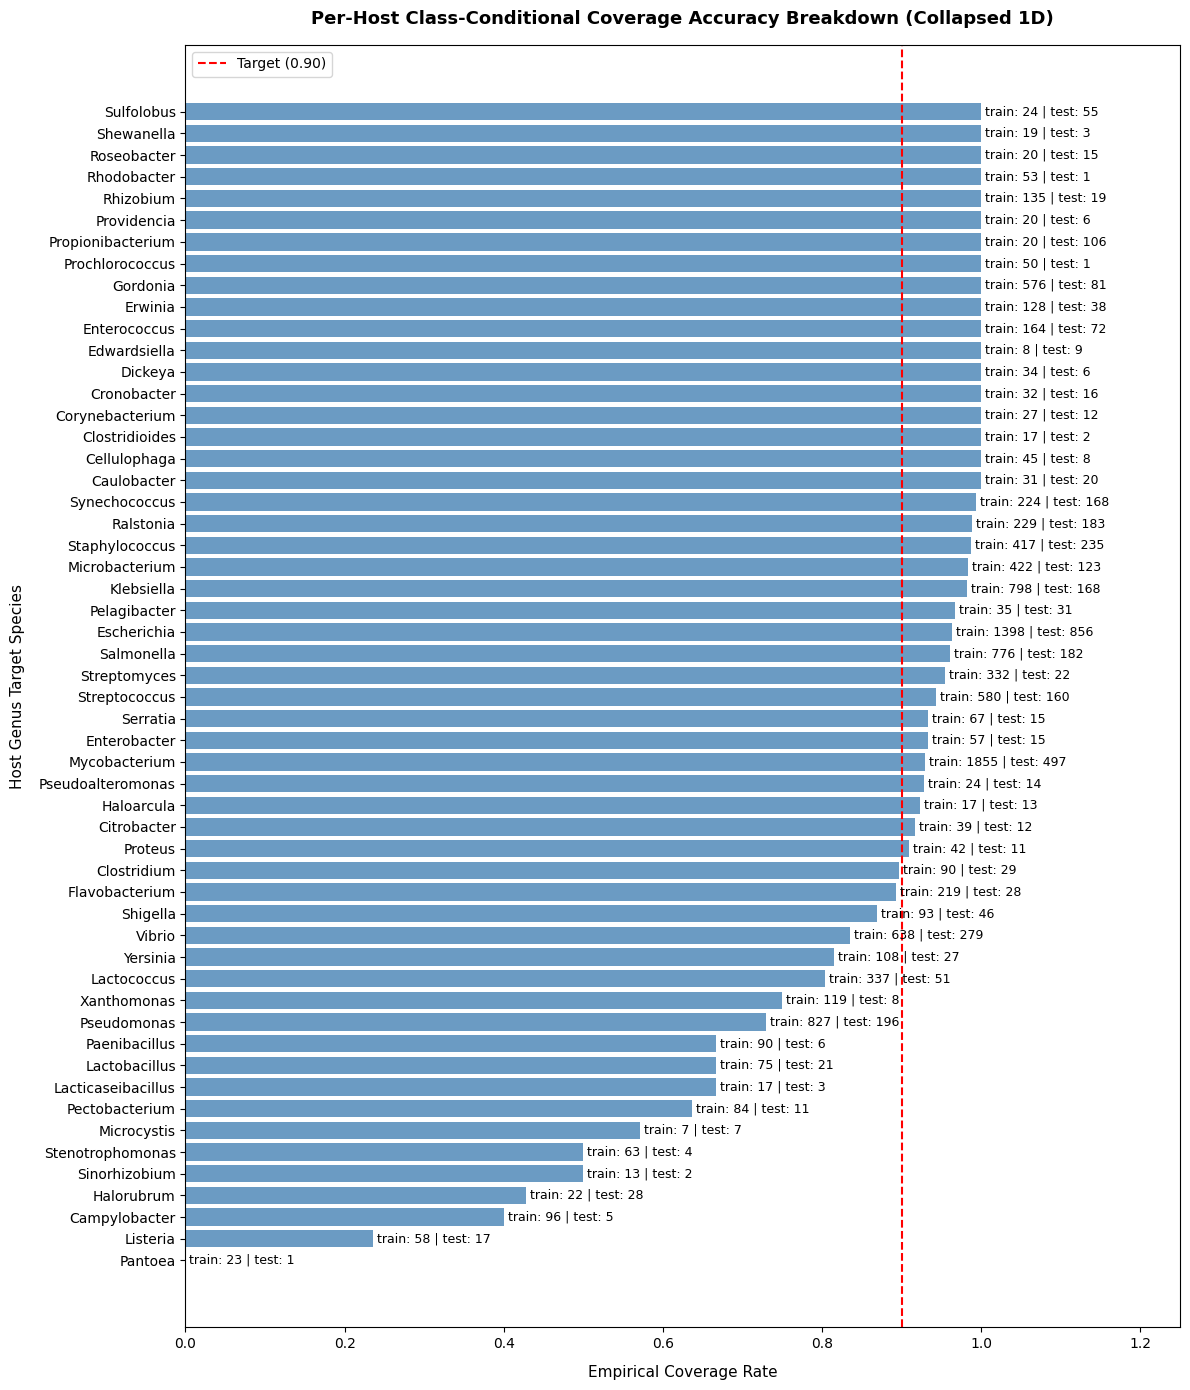

In [ ]:
# Grouping train and test data frames by host to get exact phage counts
train_counts = train_df["host"].value_counts().to_dict()
test_counts = test_df["host"].value_counts().to_dict()

host_covs = collapsed_metrics["per_host_coverage"]
hosts_sorted = sorted(host_covs, key=host_covs.get)
vals = [host_covs[h] for h in hosts_sorted]

plt.figure(figsize=(12, 14)) # Slightly widened to ensure text labels fit beautifully
bars = plt.barh(hosts_sorted, vals, color="steelblue", alpha=0.8)
plt.axvline(1 - alpha, color="red", linestyle="--", label=f"Target ({1-alpha:.2f})")

# Loop through each horizontal bar to append custom string metrics
for bar, h in zip(bars, hosts_sorted):
    # Fetch counts safely from dict maps (defaulting to 0 if missing)
    n_train = train_counts.get(h, 0)
    n_test = test_counts.get(h, 0)
    
    # Format the metrics text string
    label_text = f" train: {n_train} | test: {n_test}"
    
    # Place text directly inside/in front of each bar
    # y-coordinate is the center of the bar, x-coordinate is the coverage value
    plt.text(
        x=bar.get_width(), 
        y=bar.get_y() + bar.get_height()/2, 
        s=label_text, 
        va='center', 
        ha='left', 
        fontsize=9, 
        fontweight='medium',
        color='black'
    )

# Formatting labels and clean bounds
plt.xlim(0, 1.25) # Extended limit so the right-side text strings do not clip out of bounds
plt.title("Per-Host Class-Conditional Coverage Accuracy Breakdown (Collapsed 1D)", fontsize=13, fontweight="bold", pad=15)
plt.xlabel("Empirical Coverage Rate", fontsize=11, labelpad=10)
plt.ylabel("Host Genus Target Species", fontsize=11, labelpad=10)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()